# Get summary statistics for the different datasets

In [1]:
# Get summary statistics for ube suitability
import dataframe_image as dfi
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

/Users/loistanglao/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [7]:
# path to suitability file
suit_data = '../data/raw/suit_data/DATA_GAEZ-V5_MAPSET_RES05-SXX_GAEZ-V5.RES05-SXX.HP0120.AGERA5.HIST.YAM.LRLM.tif'

with rasterio.open(suit_data) as src:
    for i in range(1, src.count + 1):
        band = src.read(i, masked=True)  # masked=True handles nodata
        
        print(f"Band {i}:")
        print(f"  Min:    {band.min():.2f}")
        print(f"  Q25:    {np.percentile(band.compressed(), 25):.2f}")
        print(f"  Median: {np.ma.median(band):.2f}")
        print(f"  Q75:    {np.percentile(band.compressed(), 75):.2f}")
        print(f"  Max:    {band.max():.2f}")
        print(f"  Mean:   {band.mean():.2f}")
        print(f"  Std:    {band.std():.2f}")
    

Band 1:
  Min:    0.00
  Q25:    0.00
  Median: 0.00
  Q75:    0.00
  Max:    10000.00
  Mean:   420.18
  Std:    1160.92


In [3]:
suit_data = '../data/raw/suit_data/DATA_GAEZ-V5_MAPSET_RES05-SXX_GAEZ-V5.RES05-SXX.HP0120.AGERA5.HIST.YAM.LRLM.tif'

stats = []

with rasterio.open(suit_data) as src:
    for i in range(1, src.count + 1):
        band = src.read(i, masked=True)
        compressed = band.compressed()
        
        print(f"Band {i}:")
        print(f"  Min:    {compressed.min():.2f}")
        print(f"  Q25:    {np.percentile(compressed, 25):.2f}")
        print(f"  Median: {np.ma.median(band):.2f}")
        print(f"  Q75:    {np.percentile(compressed, 75):.2f}")
        print(f"  Max:    {compressed.max():.2f}")
        print(f"  Mean:   {band.mean():.2f}")
        print(f"  Std:    {band.std():.2f}")

        # collect into list
        stats.append({
            "Band": i,
            "Min": compressed.min(),
            "Q25": np.percentile(compressed, 25),
            "Median": np.ma.median(band),
            "Q75": np.percentile(compressed, 75),
            "Max": compressed.max(),
            "Mean": float(band.mean()),
            "Std": float(band.std()),
        })

# build and export table
df = pd.DataFrame(stats).set_index("Band").round(2)

df_styled = df.style.set_caption("Raster Summary Statistics") \
                    .format("{:.2f}")

dfi.export(df_styled, "stats_table.png")
print("Saved to stats_table.png")

Band 1:
  Min:    0.00
  Q25:    0.00
  Median: 0.00
  Q75:    0.00
  Max:    10000.00
  Mean:   420.18
  Std:    1160.92


AttributeError: 'Styler' object has no attribute 'render'

Saved to stats_table.png


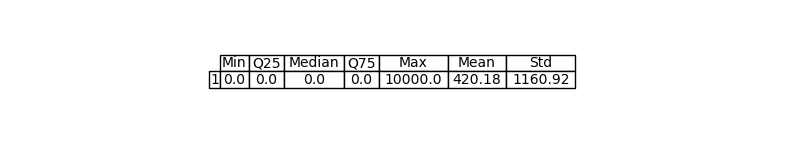

In [5]:
fig, ax = plt.subplots(figsize=(10, len(df) * 0.6 + 1))
ax.axis("off")
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df.columns))))
plt.savefig("stats_table.png", dpi=300, bbox_inches="tight")
print("Saved to stats_table.png")

## Get summary statistics for cleaned NNS data

In [4]:
# Load in merged dataset
merged_data = pd.read_csv('../data/processed/merged_18_19_21.csv')

In [8]:
# Get summary statistics for BMI in merged dataset
bmi_stats = merged_data['bmi'].describe()
print("BMI Summary Statistics:")
print(bmi_stats)

BMI Summary Statistics:
count    432313.000000
mean         20.766169
std           5.213630
min           6.579307
25%          16.327720
50%          20.254054
75%          24.302298
max          66.382983
Name: bmi, dtype: float64


In [11]:
# export this to an image
bmi_stats_df = bmi_stats.to_frame().T.round(2)
dfi.export(bmi_stats_df, "../output/bmi_stats_table.png")

[5247:271194:0518/200646.515329:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200646.517331:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200646.517697:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200646.518088:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200647.345687:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200647.363325:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200647.789567:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5247:271194:0518/200647.789939:ER

In [13]:
# check how many unique values there are in name_lower_cleaned
unique_names = merged_data['name_lower_cleaned'].nunique()
unique_names

112

## Get summary statistics for cleaned yam suitability data

In [9]:
# Get summary statistics for suitability in merged dataset
suit_stats = merged_data['yam_suitability'].describe()
print("\nYam Suitability Summary Statistics:")
print(suit_stats)


Yam Suitability Summary Statistics:
count    433172.000000
mean       1955.901618
std        1012.717650
min           0.000000
25%        1409.595506
50%        1839.981818
75%        2388.642857
max        6369.818182
Name: yam_suitability, dtype: float64


In [12]:
# export yam suit summary stats to an image
suit_stats_df = suit_stats.to_frame().T.round(2)
dfi.export(suit_stats_df, "../output/suit_stats_table.png")

[5272:272342:0518/200738.482420:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200738.483983:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200738.485420:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200738.485928:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200739.271911:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200739.283991:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200739.643929:ERROR:ui/display/mac/cv_display_link_mac.mm:184] CVDisplayLinkCreateWithCGDisplay failed. CVReturn: -6670
[5272:272342:0518/200739.644264:ER